# 02 — Experiment 1: SCM in tokenizer latent space (biweekly panel)

The collaborator's notebook-14 workflow, transplanted into the tokenizer latent space:
donor weights are fit on early pre-hurricane periods, frozen, and scored on held-out
late pre-hurricane periods where the treated sites' true (untreated) latents are
observed. The optimization is identical to notebook 14's — **find** w₁…w₅ (one per
donor), **subject to** wⱼ ≥ 0 and Σw = 1 (a weighted average, no extrapolation),
**minimizing** the mean squared difference between the treated site's z-scored latent
and the weighted donor mix, over fit-window periods × all 980 latent dimensions,
jointly, per site × sensor (SLSQP, ftol 1e-12, maxiter 5000, init 1/5).

**What differs from notebook 14 (all Jun-approved 2026-08-19):**
- outcome space = the 980-d tokenizer quantized latent (not the 11 chip-mean features);
- **donors = 5 nearest neighbors in latent space** per treated site × sensor, selected
  from every control that has panel imagery (the 50), using P01–P08 latents only
  (notebook 14 uses the site's own 5 covariate-matched controls). This is **not**
  the `embed_DiD` 260-control kNN: 210 of those sites have no P01–P20 chip, hence no
  latent. Searching 260 would be new data collection, not a missing filter here;
- **two validation schemes**: `frozen_joint` = notebook 14's (w8 fit on P01–P08, scored
  on P09+P10 pooled) and `expanding` = the advisor's (w8 → P09; w9 fit on P01–P09 → P10);
- **two flags**: notebook-14's ratio (holdout/training ≤1.5 good, ≤2.0 caution, else poor)
  AND whether holdout RMSPE beats the mean predictor (RMSPE < 1 after P01–P08 z-scoring).
  Ratio alone misses fits that are equally bad in and out of sample. CSV `flag_level`
  still stores pass/FAIL; this is not a named “1-SD test”;
- P11–P20 effects are computed **and inspected** (notebook 14 only wrote them to CSV);
- a quality-sensitivity arm (`quality40`): donor selection + fits + validation repeated
  with site-periods below 40% valid pixels dropped (tables only). The filter thins the
  S2 pre-period so much that the main arm's ≥4-shared-period donor rule can leave zero
  candidates; the sensitivity arm therefore relaxes it to ≥2 and RECORDS any site ×
  sensor that remains not estimable instead of estimating it on nothing.

**Conventions**: z-scoring per sensor × latent-dim, pooled over all 60 sites, periods
P01–P08 only, ddof=1, zero-SD dims → 1 (mirrors notebook 14's scaler; kept fixed for the
P01–P09 fit and for the sensitivity arm so every RMSPE is in the same units). A period
enters a fit or metric only if the treated site AND all 5 donors have latents (notebook
14's rule). Holdout RMSPE = √mean((z − Xw)²) over periods × 980 dims, in P01–P08 SD units
(Abadie RMSPE on z-scored outcomes). After that scaling, RMSPE of the pooled mean is 1.

**Inputs**: `../../data/embeddings_tok_panel/latents_biweekly.npz`,
`panel_latent_index.csv`, `../../data/daily_datasets/selected_site_sample.csv`.
**Outputs**: `panel_knn_donors.csv`, `panel_scm_weights.csv`, `panel_scm_validation.csv`,
`panel_scm_effects.csv`, figures.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
TS = ROOT / "REAP" / "notebooks" / "ts_SCM_ASCM"
LATD = ROOT / "REAP" / "data" / "embeddings_tok_panel"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

SENSORS = ("sentinel1", "sentinel2")
TRAIN8 = list(range(1, 9))          # P01–P08
TRAIN9 = list(range(1, 10))         # P01–P09
VAL = {"P09": 9, "P10": 10}
POST = list(range(11, 21))          # P11–P20
J = 5                               # donors per treated site

idx = pd.read_csv(TS / "panel_latent_index.csv")
roster = pd.read_csv(ROOT / "REAP" / "data" / "daily_datasets" / "selected_site_sample.csv")
treatments = sorted(roster.query("group == 'treatment'")["site_id"])
controls = sorted(roster.query("group == 'counterfactual'")["site_id"])
assert len(treatments) == 10 and len(controls) == 50

_z = np.load(LATD / "latents_biweekly.npz")
lat = {tuple(k.split("|")): _z[k].ravel().astype(np.float64) for k in _z.files}
D = len(next(iter(lat.values())))
print(f"{len(lat)} latents loaded, D = {D}")

seq_of = idx.set_index(["site_id", "sensor", "period_id"])["seq"].to_dict()
pid_of_seq = {v: k[2] for k, v in seq_of.items()}   # seq -> period_id (any row)
vfrac = idx.set_index(["site_id", "sensor", "period_id"])["valid_pixel_fraction"].to_dict()

def L(site, sensor, seq):
    """latent vector or None; seq 1..20."""
    return lat.get((site, sensor, pid_of_seq[seq]))

def ok(site, sensor, seq, arm):
    v = lat.get((site, sensor, pid_of_seq[seq]))
    if v is None:
        return False
    if arm == "quality40":
        f = vfrac.get((site, sensor, pid_of_seq[seq]), np.nan)
        return bool(np.isfinite(f) and f >= 0.40)
    return True
print("periods:", sorted(pid_of_seq.items())[:3], "...")

2322 latents loaded, D = 980
periods: [(1, 'before_P01'), (2, 'before_P02'), (3, 'before_P03')] ...


## Z-scoring (pooled, P01–P08, fixed for everything downstream)

In [2]:
scaler = {}
for sensor in SENSORS:
    X = np.stack([lat[(s, sensor, pid_of_seq[q])] for s in roster["site_id"]
                  for q in TRAIN8 if (s, sensor, pid_of_seq[q]) in lat])
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=1)
    sd[~np.isfinite(sd) | (sd == 0)] = 1.0
    scaler[sensor] = (mu, sd)
    print(f"{sensor}: scaler from {len(X)} site-periods; "
          f"median dim SD = {np.median(sd):.4f}, zero-SD dims = {(sd == 1.0).sum()}")

def Z(site, sensor, seq):
    v = L(site, sensor, seq)
    if v is None:
        return None
    mu, sd = scaler[sensor]
    return (v - mu) / sd

sentinel1: scaler from 468 site-periods; median dim SD = 0.3038, zero-SD dims = 0
sentinel2: scaler from 480 site-periods; median dim SD = 0.2061, zero-SD dims = 0


## Donor selection — 5 nearest neighbors in latent space (P01–P08 only)

Distance between a treated site and a control = the mean over shared available P01–P08
periods of the Euclidean distance between their (unscaled) flattened latents; periods
missing for either site are skipped. The overlap with the site's own 5 covariate-matched
controls is printed for context only.

**Search pool is the 50 panel controls, not the snapshot-era 260.** kNN needs
`encode(control image)`. `biweekly_datasets/` and `latents_biweekly.npz` cover only the
60-site sample (10 treated + top-5 matched = 50 controls). Of `site_matching_table.csv`'s
260 controls, 210 have no P01–P20 GeoTIFF (ranks 6–10 of treatments 0001–0010, and all
controls of 0011–0026), so they cannot enter the neighbor list. `embed_DiD` could search
all 260 because those were two-snapshot chips. Here, looping `panel.controls` already
searches every site that exists in this dataset. The remaining “5” is how many of those
50 are kept for the simplex.

In [3]:
cov5 = {t: sorted(roster.query("matched_treatment_site_id == @t and control_rank <= 5")
                  ["site_id"]) for t in treatments}

don_rows, donors, not_estimable = [], {}, []
for arm in ("main", "quality40"):
    donors[arm] = {}
    min_shared = 4 if arm == "main" else 2   # the 40% filter thins S2 pre-periods;
                                             # the sensitivity arm relaxes to 2
    for sensor in SENSORS:
        for tid in treatments:
            scores = []
            for c in controls:
                sh = [q for q in TRAIN8 if ok(tid, sensor, q, arm) and ok(c, sensor, q, arm)]
                if len(sh) < min_shared:
                    continue
                d = np.mean([np.linalg.norm(L(tid, sensor, q) - L(c, sensor, q))
                             for q in sh])
                scores.append((d, c, len(sh)))
            scores.sort()
            if arm == "main":
                assert len(scores) >= J, (arm, sensor, tid, len(scores))
            if len(scores) < J:
                donors[arm][(sensor, tid)] = None
                not_estimable.append({"arm": arm, "sensor": sensor,
                                      "treatment_site_id": tid,
                                      "n_candidates": len(scores)})
                continue
            donors[arm][(sensor, tid)] = [c for _, c, _ in scores[:J]]
            for rank, (d, c, nsh) in enumerate(scores[:J], start=1):
                don_rows.append({"arm": arm, "sensor": sensor,
                                 "treatment_site_id": tid,
                                 "counterfactual_site_id": c, "rank": rank,
                                 "distance": float(d), "n_shared_periods": nsh})

don = pd.DataFrame(don_rows)
assert len(don.query("arm == 'main'")) == 2 * 10 * J
don.to_csv(TS / "panel_knn_donors.csv", index=False)
print("saved:", TS / "panel_knn_donors.csv", don.shape)
if not_estimable:
    print("\nNOT ESTIMABLE under the quality-40 filter (recorded, skipped):")
    print(pd.DataFrame(not_estimable).to_string(index=False))

print("\ndonor overlap with the site's own 5 covariate-matched controls (main arm):")
for sensor in SENSORS:
    ov = [len(set(donors["main"][(sensor, t)]) & set(cov5[t])) for t in treatments]
    print(f"  {sensor}: per-site overlap {ov}  (mean {np.mean(ov):.1f} of 5)")
print("\nkNN donors come from these matched clusters (main arm, sentinel2 example):")
for t in treatments[:3]:
    print(f"  {t}: {donors['main'][('sentinel2', t)]}")

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/ts_SCM_ASCM/panel_knn_donors.csv (200, 7)

donor overlap with the site's own 5 covariate-matched controls (main arm):
  sentinel1: per-site overlap [0, 1, 1, 0, 1, 1, 1, 1, 1, 0]  (mean 0.7 of 5)
  sentinel2: per-site overlap [1, 0, 1, 2, 0, 1, 1, 1, 2, 0]  (mean 0.9 of 5)

kNN donors come from these matched clusters (main arm, sentinel2 example):
  treatment_0001: ['counterfactual_0004_03', 'counterfactual_0007_03', 'counterfactual_0008_02', 'counterfactual_0006_04', 'counterfactual_0001_05']
  treatment_0002: ['counterfactual_0006_05', 'counterfactual_0003_05', 'counterfactual_0003_03', 'counterfactual_0010_04', 'counterfactual_0010_05']
  treatment_0003: ['counterfactual_0009_03', 'counterfactual_0009_05', 'counterfactual_0007_02', 'counterfactual_0008_03', 'counterfactual_0003_04']


## SCM fits — w8 (P01–P08) and w9 (P01–P09)

In [4]:
def scm_fit(y, X):
    """y (T,D), X (J,T,D) z-scored, no NaN. Returns simplex weights (J,)."""
    Jn = X.shape[0]
    yf = y.reshape(-1)
    Xf = X.reshape(Jn, -1).T                      # (T*D, J)
    def obj(w):
        r = yf - Xf @ w
        return float(np.mean(r * r))
    res = minimize(obj, np.full(Jn, 1.0 / Jn), method="SLSQP",
                   bounds=[(0.0, 1.0)] * Jn,
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
                   options={"maxiter": 5000, "ftol": 1e-12})
    assert res.success, res.message
    w = res.x
    assert abs(w.sum() - 1.0) < 1e-6
    return w

def usable(tid, sensor, seqs, dl, arm):
    return [q for q in seqs
            if ok(tid, sensor, q, arm) and all(ok(c, sensor, q, arm) for c in dl)]

def design(tid, sensor, seqs, dl):
    y = np.stack([Z(tid, sensor, q) for q in seqs])
    X = np.stack([np.stack([Z(c, sensor, q) for q in seqs]) for c in dl])
    return y, X

def rmse_of(w, tid, sensor, seqs, dl):
    y, X = design(tid, sensor, seqs, dl)
    r = y - np.tensordot(w, X, axes=1)
    return float(np.sqrt(np.mean(r * r)))

w_rows, W = [], {}
for arm in ("main", "quality40"):
    for sensor in SENSORS:
        for tid in treatments:
            dl = donors[arm][(sensor, tid)]
            if dl is None:
                continue
            for wname, window in (("P01-08", TRAIN8), ("P01-09", TRAIN9)):
                seqs = usable(tid, sensor, window, dl, arm)
                if arm == "main":
                    assert len(seqs) >= 2, (arm, sensor, tid, wname, seqs)
                if len(seqs) < 2:
                    W[(arm, sensor, tid, wname)] = None
                    continue
                y, X = design(tid, sensor, seqs, dl)
                w = scm_fit(y, X)
                W[(arm, sensor, tid, wname)] = (w, dl, seqs)
                for c, wi in zip(dl, w):
                    w_rows.append({"arm": arm, "sensor": sensor,
                                   "treatment_site_id": tid, "fit_window": wname,
                                   "donor": c, "weight": float(wi),
                                   "largest_donor_weight": float(w.max()),
                                   "effective_donors": float(1.0 / np.sum(w ** 2)),
                                   "n_train_periods": len(seqs)})

wdf = pd.DataFrame(w_rows)
assert len(wdf.query("arm == 'main'")) == 2 * 10 * 2 * J
wdf.to_csv(TS / "panel_scm_weights.csv", index=False)
print("saved:", TS / "panel_scm_weights.csv", wdf.shape)
print("\nsmall training sets (n_train_periods < 8, main arm, w8):")
small = wdf.query("arm == 'main' and fit_window == 'P01-08' and n_train_periods < 8")
print(small[["sensor", "treatment_site_id", "n_train_periods"]].drop_duplicates()
      .to_string(index=False) if len(small) else "  none")

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/ts_SCM_ASCM/panel_scm_weights.csv (400, 9)

small training sets (n_train_periods < 8, main arm, w8):
   sensor treatment_site_id  n_train_periods
sentinel1    treatment_0007                4
sentinel1    treatment_0008                4
sentinel1    treatment_0010                4


## Validation — both schemes

`frozen_joint` = notebook 14's workflow (w8 scored on P09+P10 pooled).
`expanding` = the advisor's (w8 → P09; w9 → P10). Flags: notebook-14 ratio (≤1.5 good / ≤2.0
caution / >2.0 poor) and whether holdout RMSPE beats the mean predictor (`flag_level` pass if RMSPE < 1).

In [5]:
def flags(train, valid):
    ratio = valid / train if train > 0 else np.inf
    fr = "good" if ratio <= 1.5 else ("caution" if ratio <= 2.0 else "poor")
    return ratio, fr, ("pass" if valid < 1.0 else "FAIL")

val_rows = []
for arm in ("main", "quality40"):
    for sensor in SENSORS:
        for tid in treatments:
            f8 = W.get((arm, sensor, tid, "P01-08"))
            f9 = W.get((arm, sensor, tid, "P01-09"))
            if f8 is None or f9 is None:
                continue
            w8, dl, seqs8 = f8
            w9, _, seqs9 = f9
            tr8 = rmse_of(w8, tid, sensor, seqs8, dl)
            tr9 = rmse_of(w9, tid, sensor, seqs9, dl)
            # frozen_joint: w8 on P09+P10 pooled
            vs = usable(tid, sensor, [9, 10], dl, arm)
            entries = [("frozen_joint", "pooled", w8, tr8, vs, len(seqs8))]
            # expanding: w8 -> P09, w9 -> P10
            entries += [("expanding", "P09", w8, tr8,
                         usable(tid, sensor, [9], dl, arm), len(seqs8)),
                        ("expanding", "P10", w9, tr9,
                         usable(tid, sensor, [10], dl, arm), len(seqs9))]
            for scheme, ep, w, tr, seqs, ntr in entries:
                if not seqs:
                    val_rows.append({"arm": arm, "sensor": sensor,
                                     "treatment_site_id": tid, "scheme": scheme,
                                     "eval_period": ep, "train_rmse": tr,
                                     "valid_rmse": np.nan, "ratio": np.nan,
                                     "flag_ratio": "no_data", "flag_level": "no_data",
                                     "n_train_periods": ntr, "n_valid_periods": 0})
                    continue
                v = rmse_of(w, tid, sensor, seqs, dl)
                ratio, fr, fl = flags(tr, v)
                val_rows.append({"arm": arm, "sensor": sensor,
                                 "treatment_site_id": tid, "scheme": scheme,
                                 "eval_period": ep, "train_rmse": tr, "valid_rmse": v,
                                 "ratio": ratio, "flag_ratio": fr, "flag_level": fl,
                                 "n_train_periods": ntr, "n_valid_periods": len(seqs)})

val = pd.DataFrame(val_rows)
assert len(val.query("arm == 'main'")) == 2 * 10 * 3
val.to_csv(TS / "panel_scm_validation.csv", index=False)
print("saved:", TS / "panel_scm_validation.csv", val.shape)

for arm in ("main", "quality40"):
    print(f"\n=== {arm} arm — holdout RMSPE (SD units) ===")
    v = val.query("arm == @arm")
    piv = v.query("scheme == 'frozen_joint'").pivot_table(
        index="treatment_site_id", columns="sensor", values="valid_rmse")
    exp = v.query("scheme == 'expanding'").pivot_table(
        index="treatment_site_id", columns=["sensor", "eval_period"],
        values="valid_rmse")
    print("frozen_joint (notebook-14 scheme):"); print(piv.round(3))
    print("expanding (advisor scheme):"); print(exp.round(3))
    bad = v.query("flag_ratio == 'poor' or flag_level == 'FAIL'")
    print("flagged:", bad[["sensor", "treatment_site_id", "scheme", "eval_period",
                           "valid_rmse", "ratio", "flag_ratio", "flag_level"]]
          .to_string(index=False) if len(bad) else "none")

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/ts_SCM_ASCM/panel_scm_validation.csv (120, 12)

=== main arm — holdout RMSPE (SD units) ===
frozen_joint (notebook-14 scheme):
sensor             sentinel1  sentinel2
treatment_site_id                      
treatment_0001         1.077      1.182
treatment_0002         1.075      1.221
treatment_0003         1.035      0.927
treatment_0004         1.065      1.376
treatment_0005         1.064      1.190
treatment_0006         1.072      1.232
treatment_0007         1.051      1.084
treatment_0008         1.051      1.134
treatment_0009         1.054      1.226
treatment_0010         1.040      1.232
expanding (advisor scheme):
sensor            sentinel1        sentinel2       
eval_period             P09    P10       P09    P10
treatment_site_id                                  
treatment_0001        1.068  1.086     1.066  1.285
treatment_0002        1.064  1.085     1.233  1.202
treatment_0003        1.040  1.031

## Effects P11–P20 (w8, main arm) — computed AND inspected

`latent_gap_norm` = √mean((z_treated − z_synthetic)²) over the 980 dims — same units as
the holdout RMSPE, so pre-period fit, held-out error, and post-period effect sit on
one scale. The pre-period gaps (P01–P10) are plotted alongside for context.

In [6]:
eff_rows, traj = [], {}
for sensor in SENSORS:
    for tid in treatments:
        w8, dl, _ = W[("main", sensor, tid, "P01-08")]
        series = {}
        for q in range(1, 21):
            have_t = ok(tid, sensor, q, "main")
            have_d = all(ok(c, sensor, q, "main") for c in dl)
            g = np.nan
            if have_t and have_d:
                zt = Z(tid, sensor, q)
                zs = np.tensordot(w8, np.stack([Z(c, sensor, q) for c in dl]), axes=1)
                g = float(np.sqrt(np.mean((zt - zs) ** 2)))
            series[q] = g
            if q >= 11:
                eff_rows.append({"sensor": sensor, "treatment_site_id": tid,
                                 "period": f"P{q}", "latent_gap_norm": g,
                                 "treated_latent_present": have_t,
                                 "donors_present": have_d})
        traj[(sensor, tid)] = series

eff = pd.DataFrame(eff_rows)
assert len(eff) == 2 * 10 * 10
eff.to_csv(TS / "panel_scm_effects.csv", index=False)
print("saved:", TS / "panel_scm_effects.csv", eff.shape)

print("\nmean post-period latent gap vs mean pre-period gap (main arm, w8):")
for sensor in SENSORS:
    pre = np.nanmean([traj[(sensor, t)][q] for t in treatments for q in range(1, 11)])
    post = np.nanmean([traj[(sensor, t)][q] for t in treatments for q in POST])
    print(f"  {sensor}: pre {pre:.3f} -> post {post:.3f}  (ratio {post/pre:.2f})")

saved: /data/wang/junh/githubs/latent-synthetic-control/REAP/notebooks/ts_SCM_ASCM/panel_scm_effects.csv (200, 6)

mean post-period latent gap vs mean pre-period gap (main arm, w8):
  sentinel1: pre 1.056 -> post 1.056  (ratio 1.00)
  sentinel2: pre 0.887 -> post 1.163  (ratio 1.31)


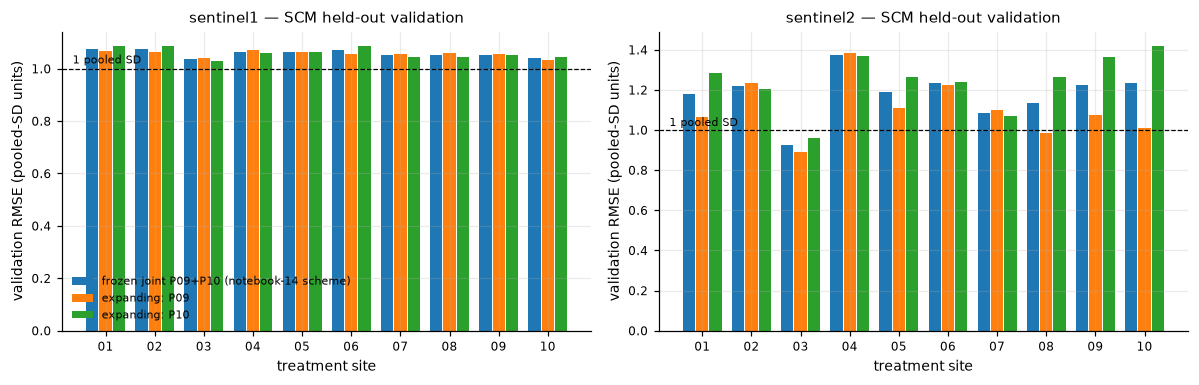

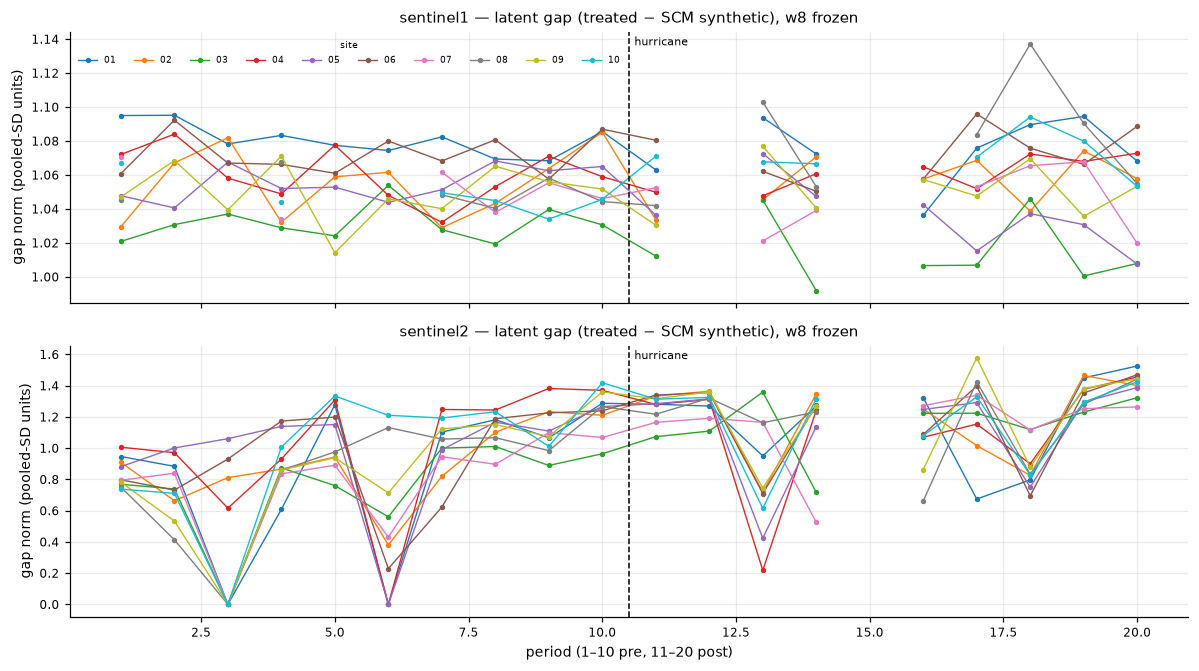

figures saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for ax, sensor in zip(axes, SENSORS):
    sub = val.query("arm == 'main' and sensor == @sensor")
    x = np.arange(len(treatments))
    fj = sub.query("scheme == 'frozen_joint'").set_index("treatment_site_id") \
            .loc[treatments, "valid_rmse"]
    e9 = sub.query("scheme == 'expanding' and eval_period == 'P09'") \
            .set_index("treatment_site_id").loc[treatments, "valid_rmse"]
    e10 = sub.query("scheme == 'expanding' and eval_period == 'P10'") \
             .set_index("treatment_site_id").loc[treatments, "valid_rmse"]
    ax.bar(x - 0.27, fj, 0.25, label="frozen joint P09+P10 (notebook-14 scheme)")
    ax.bar(x, e9, 0.25, label="expanding: P09")
    ax.bar(x + 0.27, e10, 0.25, label="expanding: P10")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.text(0.02, 1.02, "mean baseline", transform=ax.get_yaxis_transform(), fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels([t[-2:] for t in treatments])
    ax.set_xlabel("treatment site"); ax.set_title(f"{sensor} — SCM holdout RMSPE")
    ax.set_ylabel("holdout RMSPE (SD units)")
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(TS / "panel_scm_validation.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)
for ax, sensor in zip(axes, SENSORS):
    for tid in treatments:
        s = traj[(sensor, tid)]
        ax.plot(list(s.keys()), list(s.values()), marker="o", ms=2.5, lw=0.9,
                label=tid[-2:])
    ax.axvline(10.5, color="k", lw=1.0, ls="--")
    ax.text(10.6, 0.95, "hurricane", transform=ax.get_xaxis_transform(), fontsize=7)
    ax.set_title(f"{sensor} — latent gap (treated − SCM synthetic), w8 frozen")
    ax.set_ylabel("gap norm (pooled-SD units)")
axes[1].set_xlabel("period (1–10 pre, 11–20 post)")
axes[0].legend(ncol=10, frameon=False, fontsize=6, title="site", title_fontsize=6)
fig.tight_layout()
fig.savefig(TS / "panel_scm_effect_trajectories.png", bbox_inches="tight")
plt.show()
print("figures saved")

## Reading

**The headline result is negative, and it is the fit itself, not overfitting.**
Holdout RMSPE sits at the mean baseline (≈ 1) for every site and both sensors (S1 1.03–1.09;
S2 0.89–1.44, both schemes) — and the training RMSPE is the same (all ratios ≈ 1, every
ratio flag "good", every `flag_level` FAIL, the one near-pass being treatment_0003 S2 at
0.89–0.93). In plain English: **a weighted average of 5 donor latents cannot approximate
a treated site's latent any better than just using the overall mean of all sites.** The
980 latent dimensions mostly encode each site's specific spatial layout, which no other
site shares, so there is nothing for the weights to fit — per dimension, the donor span
simply does not reach the target. The quality-40 sensitivity arm does not change this
(S2 stays 0.89–1.44), so it is not an image-quality problem in this space.

Two secondary observations: the latent-kNN donors overlap the covariate-matched donors
only 0.7/5 (S1) and 0.9/5 (S2) on average — the latent metric ranks controls very
differently from land-cover/terrain matching; and several S1 fits train on only 4 of 8
periods (missing acquisitions in the treatment_0007/0008/0010 clusters).

**Effects (P11–P20):** the mean latent gap moves from 1.06 (pre) to 1.06 (post) for S1 —
no hurricane signal above this saturated baseline — and from 0.89 to 1.16 for S2 (+31%),
so a post-hurricane divergence IS visible for S2, but on top of a pre-period error that
already equals the cross-site spread. Per-latent-dimension effect measurement is
noise-dominated; the decoded feature-space view (notebook 04) is the usable readout.

**Comparison with the feature-based pipeline** (collaborator's notebook 14 — different
space and scaler, so each pipeline is compared only to its own mean baseline of 1):
feature-space SCM holdout RMSPE is 0.18–0.78 in their training-SD units (S1 mostly ≪ 1),
i.e. it clearly beats predicting the mean, while latent-space SCM does not beat its own.
Fitting weights on 11 chip-mean features works; fitting them on 980 spatial latent
dimensions does not.

**Data limit, not a kNN filter:** this search used all 50 controls with panel imagery.
It did not search the `embed_DiD` 260 because 210 of those sites have no P01–P20 image
(see this folder's README). Whether a closer donor lives in that 210 is untestable until
those sites are collected.